# match_shapes.ipynb

This Jupyter notebook explores an alternate way of filtering shapes in a diff_mask to differentiate between vcuts and artifacts.

Currently, diff_masks are created by performing a bitwise difference between an original tree mask and an EFD reconstruction of the original mask (see [efd_find_cuts.py](efd_find_cuts.py).
```python
diff_mask = reconstructed_mask & ~original_mask
```

I NEED TO CHECK IF THIS IS EQUIVALENT TO
```
diff_mask = reconstructed_mask ^ original_mask
```

A morphological opening operation is then applied to filter out artifacts.
```
# Create clean_mask
# Define kernel (size depends on how thick the "thin" features are)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=ksize)
# Apply Opening
clean_mask = cv2.morphologyEx(diff_mask, cv2.MORPH_OPEN, kernel, iterations=iterations)
```

The new idea is to use a simple model to differentiate between shapes in the diff_mask.





## Reference

Gemini prompt:  Please write python code for a binary classifier for shapes "of interest" and "not of interest". I have already created a training set of contours for each shape class. I want my classifier to be based on cv2.matchShapes.

[Gemini response](https://gemini.google.com/share/1f8d2d3aa787)

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

from sim_palm import generate_palm_with_cuts
from efd_find_cuts import efd_find_cuts, plot_efd_results
from shape_clustering import ShapeClustering

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading, SelfTrainingClassifier

import cv2
import numpy as np
import random
from icecream import ic
from dataclasses import dataclass
import pandas as pd
import pickle

In [2]:
sc = ShapeClustering()
sc.fit_predict

<bound method ShapeClustering.fit_predict of <shape_clustering.ShapeClustering object at 0x754da7a21160>>

## Locating cuts in simulated palms by subtracting mask of a palm with no cuts

### Important note
Ensure that all binary masks are np.uint8 arrays containing 0 and 255. 
Bad things will happen if this if this is untrue

In [3]:
random.seed(42)
c0_contour, c0_mask = generate_palm_with_cuts(0)
original_contour, original_mask = generate_palm_with_cuts(5)

ic(np.unique(c0_mask), np.unique(original_mask))

# defects are groups of pixels that are in c0_mask but not in original_mask
# note that, in this case, defects_mask is the same as c0_mask - original_mask, 
# but using bitwise operations is more efficient and avoids issues with negative values
defects_mask = cv2.bitwise_and(c0_mask, cv2.bitwise_not(original_mask))

# Find contours
# RETR_LIST: Gets all contours without hierarchy (parents/children)
# CHAIN_APPROX_NONE: Gets the highest possible resolution (stores all boundary pixels)
contours, _ = cv2.findContours(defects_mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

# Calculate centroids
areas = []
xs = []
ys = []
for cnt in contours:
    # Calculate moments
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        areas.append(M["m00"])
        xs.append(int(M["m10"] / M["m00"]))
        ys.append(int(M["m01"] / M["m00"]))  
ic(xs, ys);
ic(areas)



ic| np.unique(c0_mask): array([  0, 255], dtype=uint8)
    np.unique(original_mask): array([  0, 255], dtype=uint8)
ic| xs: [342, 544, 459, 410, 534], ys: [443, 439, 410, 317, 311]
ic| areas: [189.5, 190.0, 142.0, 171.0, 193.5]


[189.5, 190.0, 142.0, 171.0, 193.5]

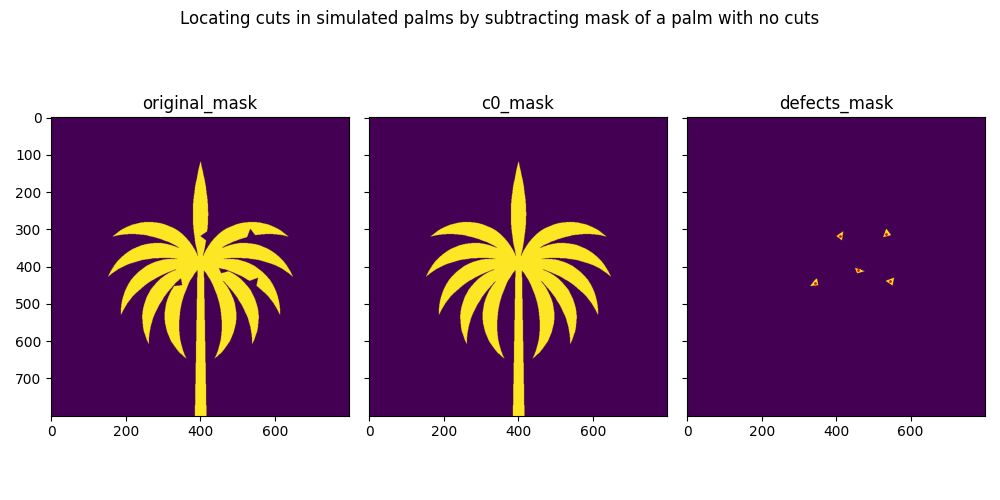

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True) 
fig.suptitle('Locating cuts in simulated palms by subtracting mask of a palm with no cuts')


axs[1].imshow(c0_mask)
axs[1].set_title('c0_mask')

axs[0].imshow(original_mask)
axs[0].set_title('original_mask')

axs[2].imshow(defects_mask)
axs[2].set_title('defects_mask')
axs[2].plot(xs, ys, 'or', ms=1)

plt.tight_layout()
plt.show;

## Locating cuts in simulated palms using EFD defects

When looking for defects on the contour of a real palm, we don't have an image of an identical palm minus defects for comparison.
However, we can calculate elliptic Fourier descriptors (EFDs) which describe the original contour.
We can then use the EFDs to reconstruct a new contour which has the same general shape as the original but smoother.
Defects (groups of pixels that are in the reconstructed contour but not in original contour) are located 
as we did in the preceding section.

```
defects_mask = cv2.bitwise_and(c0_mask, cv2.bitwise_not(original_mask))
```

As we can in the figure below, the defects mask contains the cuts we are interested in, but also a lot of artifacts from the EFD reconstruction.

In the next section we will filter out the artifacts, leaving only the cuts.

NOTE: EFD parameters need to be optimized.



In [5]:
efd_results = efd_find_cuts(original_contour, original_mask)
recon_mask = efd_results.reconstructed_mask

# Ensure both masks are binary (0 and 255) and the same size
# original_mask: source image
# recon_mask: image reconstructed from Elliptic Fourier Descriptors (EFDs)
if np.max(original_mask) == np.uint8(1):
    original_mask = original_mask * 255

if np.max(recon_mask) == np.uint8(1):
    recon_mask = recon_mask * 255

# 1. Total Defects (XOR)
total_defects = cv2.bitwise_xor(original_mask, recon_mask)

# 2. Omissions: Pixels present in original, missing in reconstruction
omissions_mask = cv2.bitwise_and(original_mask, cv2.bitwise_not(recon_mask))

# 3. Additions: Pixels missing in original, present in reconstruction
additions_mask = cv2.bitwise_and(recon_mask, cv2.bitwise_not(original_mask))

# Count defect pixels
area_original = np.sum(original_mask == 255)
area_omissions = np.sum(omissions_mask == 255)
area_additions = np.sum(additions_mask == 255)

# Calculate Error Metrics
omission_rate = area_omissions / area_original
addition_rate = area_additions / area_original
jaccard_distance = np.sum(total_defects == 255) / np.sum(cv2.bitwise_or(original_mask, recon_mask) == 255)

print(f"Missing Shape Profile: {omission_rate:.2%}")
print(f"Excess Shape Profile: {addition_rate:.2%}")
print(f"Jaccard Distance (Total Error): {jaccard_distance:.2%}")

Missing Shape Profile: 6.55%
Excess Shape Profile: 6.20%
Jaccard Distance (Total Error): 12.01%


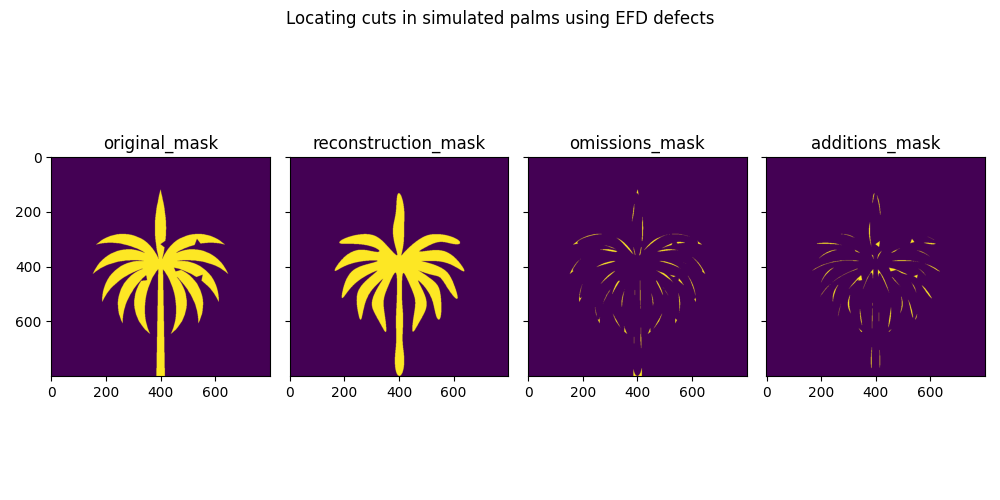

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(10, 5), sharex=True, sharey=True)
fig.suptitle('Locating cuts in simulated palms using EFD defects')

axs[0].imshow(original_mask)
axs[0].set_title('original_mask')

axs[1].imshow(recon_mask)
axs[1].set_title('reconstruction_mask')

axs[2].imshow(omissions_mask)
axs[2].set_title('omissions_mask')

axs[3].imshow(additions_mask)
axs[3].set_title('additions_mask')

plt.tight_layout()
plt.show;

### Filtering the additions_mask

This section explores development of a filter to differentiate between actual cuts and 
unwanted artifacts in the defects_mask.


In [7]:
# Create clean_mask - apply morphological opening to remove small noise and thin features from the defects_mask
# Define kernel (size depends on how thick the "thin" features are)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(3,3))
opened_mask = cv2.morphologyEx(additions_mask, cv2.MORPH_OPEN, kernel, iterations=1)    

In [8]:
opened_contours, _ = cv2.findContours(opened_mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
ic(len(opened_contours))
filtered_contours = []
for cnt in opened_contours:
    # Calculate moments
    M = cv2.moments(cnt)
    if M["m00"] >= 50:
        filtered_contours.append(cnt)
ic(len(filtered_contours))
filtered_mask = np.zeros_like(additions_mask)
filtered_mask =cv2.drawContours(filtered_mask, filtered_contours, -1, color=255, thickness=cv2.FILLED)

ic| len(opened_contours): 46
ic| len(filtered_contours): 17


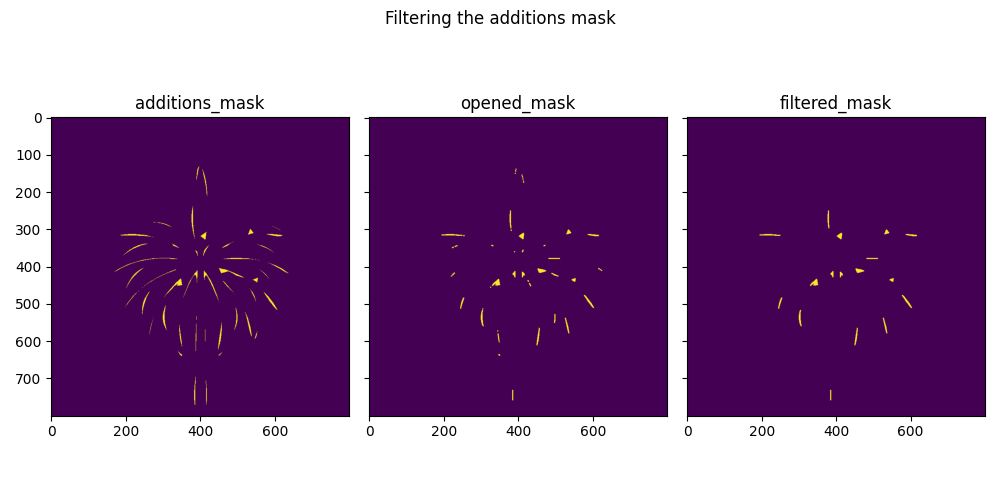

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
fig.suptitle('Filtering the additions mask')

axs[0].imshow(additions_mask)
axs[0].set_title('additions_mask')

axs[1].imshow(opened_mask)
axs[1].set_title('opened_mask')

axs[2].imshow(filtered_mask)
axs[2].set_title('filtered_mask')

plt.tight_layout()
plt.show;

# Removing EFD artifacts using a shape classifier

As you can see in the filtered_mask image in the above figure, we were able to remove most, but not all of the artifacts introduced by EFD.
We will attempt to remove the remaining noise using a shape classifier based on `cv2.matchShapes()` which uses Hu moments to match images.
Hu moments are invariant to scale, translation and rotation to match images.

Code for the classifier is in `shape-clustering.py` which should be imported using 'from shape_clustering import ShapeClustering`.

We will train the shape classifier in unsupervised mode. 

In [10]:
# wrap the workflow into a function for easier reuse and testing
def calc_filtered_contours(original_contour, original_mask):
    # original_contour, original_mask = generate_palm_with_cuts(5)
    
    efd_results = efd_find_cuts(original_contour, original_mask)
    recon_mask = efd_results.reconstructed_mask
    
    additions_mask = cv2.bitwise_and(recon_mask, cv2.bitwise_not(original_mask))
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(3, 3))
    opened_mask = cv2.morphologyEx(additions_mask, cv2.MORPH_OPEN, kernel, iterations=1)    
    opened_contours, _ = cv2.findContours(opened_mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    
    filtered_contours = []
    for cnt in opened_contours:
        # Calculate moments
        M = cv2.moments(cnt)
        if M["m00"] >= 50:
            filtered_contours.append(cnt)
            
    return filtered_contours

# test the function to make sure it produces the same filtered contours as our manual workflow
random.seed(42)
original_contour, original_mask = generate_palm_with_cuts(5)
new_filtered_contours = calc_filtered_contours(original_contour, original_mask)
for i in range(len(filtered_contours)):
    ic(i,(new_filtered_contours[i] == filtered_contours[i]).all())

ic| i: 0
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 1
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 2
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 3
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 4
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 5
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 6
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 7
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 8
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 9
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 10
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 11
    (new_filtered_contours[i] == filtered_contours[i]).all(): np.True_
ic| i: 12
    (new_filtered_contours[i

In [11]:
@dataclass
class ContourCentroid:
    id: int
    x: float
    y: float
    area: float

def get_contour_centroids(contours) -> list[ContourCentroid]:
    """Calculates centroids for a list of OpenCV contours."""
    results = []
    for i, cnt in enumerate(contours):
        M = cv2.moments(cnt)
        
        # Avoid division by zero if contour area is 0
        if M["m00"] == 0:
            continue
            
        cX = M["m10"] / M["m00"]
        cY = M["m01"] / M["m00"]
        area = cv2.contourArea(cnt)
        
        results.append(ContourCentroid(id=i, x=cX, y=cY, area=area))
    
    return results

# Example Usage:
# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)[1]
# contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# centroids = get_contour_centroids(contours)

In [12]:
random.seed(50)
c0_contour, c0_mask = generate_palm_with_cuts(0)
original_contour, original_mask = generate_palm_with_cuts(5)

cuts_mask = original_mask - c0_mask
cuts_contours, _ = cv2.findContours(cuts_mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

cuts_centroids = get_contour_centroids(cuts_contours)
ic(cuts_centroids)

filtered_contours = calc_filtered_contours(original_contour, original_mask)
filtered_mask = np.zeros_like(original_mask)
filtered_mask = cv2.drawContours(filtered_mask, filtered_contours, -1, color=255, thickness=cv2.FILLED)

# cuts_and_filtered_mask = cv2.bitwise_and(cuts_mask, filtered_mask)
 


ic| cuts_centroids: [ContourCentroid(id=0, x=318.5159362549801, y=487.62682602921643, area=251.0),
                     ContourCentroid(id=1, x=470.3398409255242, y=464.42371655820676, area=230.5),
                     ContourCentroid(id=2, x=586.4263374485596, y=447.86502057613166, area=202.5),
                     ContourCentroid(id=3, x=469.852394916911, y=415.4760508308895, area=170.5),
                     ContourCentroid(id=4, x=189.50853242320818, y=378.9590443686007, area=146.5)]


In [13]:
areas = [c.area for c in cuts_centroids]
areas

[251.0, 230.5, 202.5, 170.5, 146.5]

In [14]:
type(cuts_centroids[0])

__main__.ContourCentroid

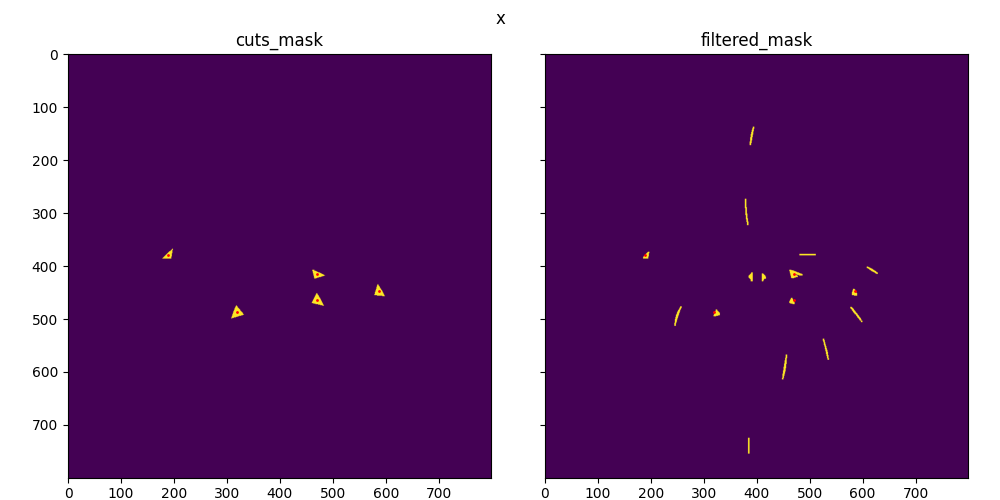

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
fig.suptitle('x')

axs[0].imshow(cuts_mask)
axs[0].set_title('cuts_mask')
axs[0].plot([c.x for c in cuts_centroids], [c.y for c in cuts_centroids], 'or', ms=1)

axs[1].imshow(filtered_mask)
axs[1].set_title('filtered_mask')
axs[1].plot([c.x for c in cuts_centroids], [c.y for c in cuts_centroids], 'or', ms=1)

plt.tight_layout()
plt.show;

# SHAPE CLASSIFIER MODEL

In this section, we build a shape classifier model which can be used to remove noise from filtered_mask.

## Important notes

Input data for the model is a list of contours (shapes). 
Use this workflow to classify the shapes:
```
features = np.array([extract_invariant_features(item['contour']) for item in shapes_dataset])
scaled_features = scaler.transform(features)
pred_y = model.predict(scaled_features)
```

## Build training set

Here we build a training set for shape clustering and return it as a pandas dataframe.
We will use the filtered_mask as the source of "defect" shapes.

We can find out if a filtered_contour is a cut by comparing it to the c0_contour

A filtered_contour is a cut if all pixels are present in the c0_contour, which represents a palm with no cuts.

A trainset for 100 images was built in only 1.7s.

In [16]:
def build_trainset(num_images=100, num_cuts=5, tolerance=3, seed=50):
    """
    Builds a training dataset by generating simulated palm images with cuts, 
    calculating filtered contours using EFD reconstruction, 
    and labeling contours as valid cuts based on proximity to cut centroids.
    """
    random.seed(seed)
    c0_contour, c0_mask = generate_palm_with_cuts(0)

    trainset = []
    id = 0
    for img_id in range(100):
        # generate mask with 5 cuts
        original_contour, original_mask = generate_palm_with_cuts(5)
        
        # get centroids for cuts
        cuts_mask = original_mask - c0_mask
        cuts_contours, _ = cv2.findContours(cuts_mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
        cuts_centroids = get_contour_centroids(cuts_contours)
        # ic(cuts_centroids)
        
        # calculate filtered contours using EFD reconstruction and morphological opening
        filtered_contours = calc_filtered_contours(original_contour, original_mask) 
        
        # determine if a contour represents a valid cut by checking if a cuts_centroid is within the contour
        # or within 'tolerance' pixels of the contour
        for fc_id, fc in enumerate(filtered_contours):
            valid_cut = False
            for cc in cuts_centroids:
                distance = cv2.pointPolygonTest(fc, (cc.x, cc.y), measureDist=True)
                if distance >= -tolerance:  # allow some tolerance (e.g., 3 pixels)
                    valid_cut = True
                    break

            trainset.append({
                'id': id,         # uid for contour
                'img_id': img_id, # uid for image
                'fc_id': fc_id,   # uid for filtered contour within image
                'contour': fc,
                'is_valid_cut': valid_cut})
            id += 1
        
    return pd.DataFrame(trainset)

# # Example usage:
# df = build_trainset()
# df.head(30)

# Semi-supervised

In [17]:
df = build_trainset()

# y: 0s and 1s; 0 = not a valid cut, 1 = cut
mylist = df['is_valid_cut'].to_list()
training_labels = [int(b) for b in mylist]

# X: log-transformed Hu Moments extracted from contours 
shapes_dataset = df.to_dict(orient='records')
# training_contours = np.array([extract_invariant_features(item['contour']) for item in shapes_dataset])
training_contours = [s['contour'] for s in shapes_dataset]

# Save the training_labels and training_contours for later use
with open('shape_interest_training_data.pkl', 'wb') as f:
    pickle.dump({'training_labels': training_labels, 'training_contours': training_contours}, f)

df

,id,img_id,fc_id,contour,is_valid_cut
0,0,0,0,"[[[383, 724]], [[383, 725]], [[383, 726]], [[3...",False
1,1,0,1,"[[[454, 567]], [[454, 568]], [[454, 569]], [[4...",False
2,2,0,2,"[[[524, 537]], [[524, 538]], [[524, 539]], [[5...",False
3,3,0,3,"[[[322, 482]], [[322, 483]], [[322, 484]], [[3...",True
4,4,0,4,"[[[576, 477]], [[576, 478]], [[576, 479]], [[5...",False
...,...,...,...,...,...
1552,1552,99,10,"[[[337, 367]], [[336, 368]], [[335, 368]], [[3...",True
1553,1553,99,11,"[[[493, 359]], [[493, 360]], [[492, 361]], [[4...",True
1554,1554,99,12,"[[[536, 347]], [[536, 348]], [[536, 349]], [[5...",True
1555,1555,99,13,"[[[465, 310]], [[464, 311]], [[463, 312]], [[4...",True


In [18]:
def extract_invariant_features(contour):
    """
    Extracts log-transformed Hu Moments from an OpenCV contour.
    These features are invariant to translation, scale, and rotation.
    """
    # Calculate moments
    moments = cv2.moments(contour)
    # Calculate 7 Hu Moments
    hu_moments = cv2.HuMoments(moments).flatten()
    
    # Log transform to handle highly varying dynamic ranges
    # Small epsilon added to prevent log(0) errors
    log_hu = []
    for m in hu_moments:
        if m != 0:
            log_hu.append(-1.0 * np.sign(m) * np.log10(np.abs(m)))
        else:
            log_hu.append(0.0)
            
    return np.array(log_hu)

In [19]:
# Data preparation for clustering

# y: 0s and 1s; 0 = not a valid cut, 1 = cut
mylist = df['is_valid_cut'].to_list()
type(mylist[0])
y = np.array(mylist, dtype=int)
ic(y[:5]);

# X: log-transformed Hu Moments extracted from contours 
shapes_dataset = df.to_dict(orient='records')
features = np.array([extract_invariant_features(item['contour']) for item in shapes_dataset])
ic(features[:5])

# Scale features (Critical step for distance-based clustering)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
ic(scaled_features[:5]);
ic(np.var(scaled_features, axis=0));

ic| y[:5]: array([0, 0, 0, 1, 0])
ic| features[:5]: array([[-8.42474693e-02, -1.60232437e-01,  2.27351757e+01,
                           1.93526988e+01,  4.07261366e+01,  1.93973578e+01,
                           4.04503884e+01],
                         [-7.23083706e-02, -1.35526057e-01,  2.05945603e+00,
                           2.21095596e+00,  4.34734007e+00,  2.18547124e+00,
                           5.47953275e+00],
                         [-1.31109017e-01, -2.54801497e-01,  1.61536678e+00,
                           1.67875419e+00,  3.32589121e+00,  1.56556510e+00,
                           5.05229752e+00],
                         [ 7.40415630e-01,  2.96675654e+00,  2.64224556e+00,
                           4.59206406e+00, -8.34607241e+00, -6.33165787e+00,
                          -8.37431288e+00],
                         [ 2.85207246e-02,  7.15278553e-02,  2.09240914e+00,
                           2.13557911e+00,  4.24959024e+00,  2.17640248e+00,
                    

In [20]:
import numpy as np
from sklearn.semi_supervised import LabelSpreading

# 1. Define your real target data (Class 0)
# X_target = np.array([
#     [0.1, 0.2],
#     [0.2, 0.1],
#     [0.15, 0.2]
# ])
X_target = scaled_features[y == 1]

# 2. Automatically generate synthetic background points (Class 1)
# Create a wider bounding box around your target data
min_bounds = X_target.min(axis=0) - 5.0
max_bounds = X_target.max(axis=0) + 5.0

# Generate random points inside this bounding box
np.random.seed(42)
random_points = np.random.uniform(low=min_bounds, high=max_bounds, size=(20, 7))

# Filter out random points that accidentally fell inside your real target cluster
distances = np.linalg.norm(random_points[:, None, :] - X_target[None, :, :], axis=-1)
min_distances_to_target = distances.min(axis=1)
X_synthetic = random_points[min_distances_to_target > 2.0]  # Safe distance threshold

# 3. Define the unlabeled test points you actually want to evaluate
# X_unlabeled = np.array([
#     [0.12, 0.18], # Close to target cluster
#     [4.5, 4.8]    # Far away from target cluster
# ])
X_unlabeled = scaled_features[y != 1]

# 4. Combine datasets and assign labels
# Class 0 = Target, Class 1 = Synthetic Outliers, -1 = Unlabeled
ic(np.shape(X_target), np.shape(X_synthetic), np.shape(X_unlabeled));
X = np.vstack([X_target, X_synthetic, X_unlabeled])

y = np.array([0] * len(X_target) + [1] * len(X_synthetic) + [-1] * len(X_unlabeled))

# 5. Fit the model
model = LabelSpreading(kernel='rbf', gamma=0.5)
model.fit(X, y)

# 6. Extract the final predictions for just your unlabeled points
unlabeled_predictions = model.transduction_[-len(X_unlabeled):]
unlabeled_probabilities = model.label_distributions_[-len(X_unlabeled):]

np.set_printoptions(precision=2)
print("Unlabeled Probabilities [Class 0, Class 1]:\n", unlabeled_probabilities[:20])
print("\nAssigned Labels (-1 converted to either 0 or 1):\n", unlabeled_predictions[:20])


Unlabeled Probabilities [Class 0, Class 1]:
 [[8.82e-04 9.99e-01]
 [1.00e+00 2.93e-05]
 [1.00e+00 8.04e-05]
 [1.00e+00 7.98e-06]
 [1.00e+00 1.90e-04]
 [1.00e+00 4.36e-07]
 [1.00e+00 3.42e-07]
 [1.00e+00 1.18e-06]
 [1.00e+00 1.31e-04]
 [1.00e+00 1.20e-04]
 [1.00e+00 4.36e-04]
 [1.53e-03 9.98e-01]
 [1.00e+00 4.05e-04]
 [1.00e+00 7.62e-05]
 [1.00e+00 1.25e-04]
 [1.00e+00 3.87e-06]
 [1.00e+00 2.78e-07]
 [1.00e+00 1.89e-07]
 [1.00e+00 3.04e-06]
 [1.00e+00 1.88e-05]]

Assigned Labels (-1 converted to either 0 or 1):
 [1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]


ic| np.shape(X_target): (431, 7)
    np.shape(X_synthetic): (20, 7)
    np.shape(X_unlabeled): (1126, 7)


## Test with filtered_contours data

In [21]:
def extract_hu_features(contour):
    """
    Extracts log-transformed Hu Moments from an OpenCV contour.
    These features are invariant to translation, scale, and rotation.
    """
    moments = cv2.moments(contour)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    # Log transform to handle varying dynamic ranges
    log_hu = []
    for m in hu_moments:
        if m != 0:
            log_hu.append(-1.0 * np.sign(m) * np.log10(np.abs(m)))
        else:
            log_hu.append(0.0)
            
    return np.array(log_hu)

In [22]:
def find_shapes_of_interest(new_contours, model_path='shape_interest_model.pkl'):
    """
    Loads the model and scaler, extracts features from new contours, 
    and returns those identified as 'of interest'.
    """
    with open(model_path, 'rb') as f:
        assets = pickle.load(f)
    
    model = assets['model']
    scaler = assets['scaler']
    
    if not new_contours:
        return []
    
    # Extract and scale features
    features = np.array([extract_hu_features(cnt) for cnt in new_contours])
    scaled_features = scaler.transform(features)
    
    # Predict
    predictions = model.predict(scaled_features)
    
    # Filter contours of interest
    interest_contours = [cnt for cnt, pred in zip(new_contours, predictions) if pred == 1]
    
    return interest_contours, predictions

found_shapes, predictions = find_shapes_of_interest(filtered_contours)
print(f"Found {len(found_shapes)} shapes of interest out of {len(filtered_contours)} new contours.")
ic(predictions);

Found 5 shapes of interest out of 16 new contours.


ic| predictions: array([0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0])


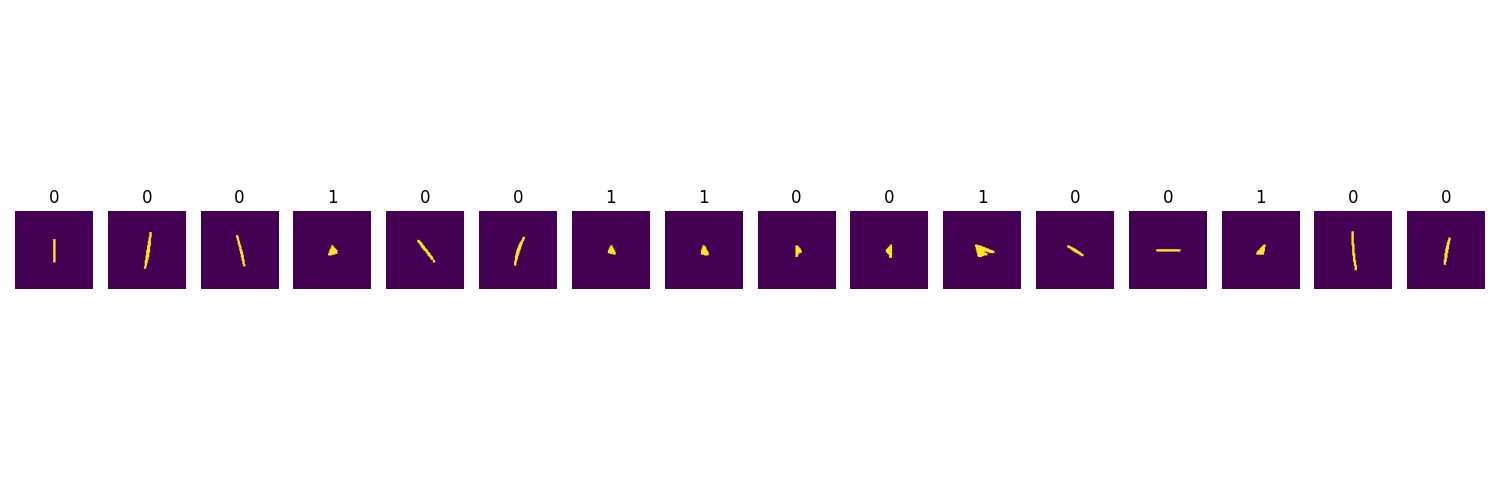

In [23]:
fig, axes = plt.subplots(1, len(filtered_contours), figsize=(15, 5))
for i, cnt in enumerate(filtered_contours):
    canvas = np.zeros((100, 100), dtype=np.uint8)
    
    # Center the contour for clear visualization thumbnail
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cnt = cnt - [cx, cy] + [50, 50]
        
    cv2.drawContours(canvas, [cnt], -1, 255, -1)
    axes[i].imshow(canvas)
    axes[i].axis('off')
    title = "valid" if predictions[i] == 1 else "invalid"
    axes[i].set_title(predictions[i])
plt.tight_layout()
plt.show()

In [34]:
canvas = np.zeros_like(original_mask)
remaining_contours = [cnt for i, cnt in enumerate(filtered_contours) if predictions[i] == 1]
remaining_contours_mask = cv2.drawContours(canvas, remaining_contours, -1, color=255, thickness=cv2.FILLED)

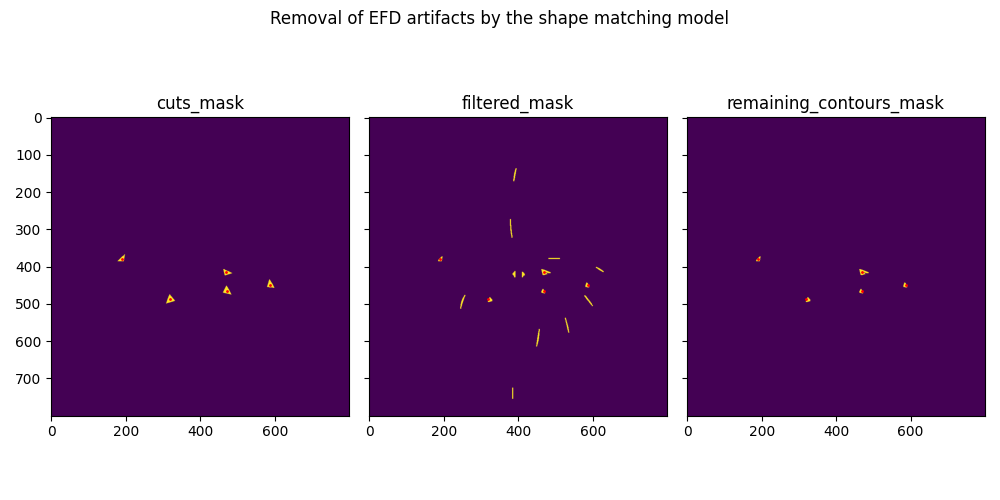

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
fig.suptitle('Removal of EFD artifacts by the shape matching model')

axs[0].imshow(cuts_mask)
axs[0].set_title('cuts_mask')
axs[0].plot([c.x for c in cuts_centroids], [c.y for c in cuts_centroids], 'or', ms=1)

axs[1].imshow(filtered_mask)
axs[1].set_title('filtered_mask')
axs[1].plot([c.x for c in cuts_centroids], [c.y for c in cuts_centroids], 'or', ms=1)

axs[2].imshow(remaining_contours_mask)
axs[2].set_title('remaining_contours_mask')
axs[2].plot([c.x for c in cuts_centroids], [c.y for c in cuts_centroids], 'or', ms=1)

plt.tight_layout()
plt.show;

# ALL CODE BELOW HAS HAS BEEN CHANGED TO RAW

## DBSCAN

# NEW STUFF

To classify new, unseen contours detected in future images, you need to save two components from your training pipeline:

- The Fitted Scaler: (StandardScaler) so new feature vectors are normalized exactly like the training data.

- The Cluster Exemplars/Centroids: Since DBSCAN doesn't use standard centroids like K-Means, you classify new shapes using a 1-Nearest Neighbor (1-NN) approach against your finalized, verified training clusters.

Here is the production-ready code to save your model, load it, and classify incoming shapes on the fly.

## 1. Saving the Trained Model Components

Use Python's native pickle library to package the scaler, the training features, and their verified cluster labels into a single file.

## 2. Live Classification Pipeline for New Images

When a new image is processed, you detect its contours, extract the invariant features, scale them using the saved scaler, and map them to the nearest cluster.

## Key Considerations for Production

- Setting the distance_threshold: In the classification function, the distance_threshold acts as a security guard. If an object passes by that looks absolutely nothing like your training classes, its distance in vector space will be high. A threshold between 1.0 and 2.0 is usually a safe sweet spot after standard scaling.

- Contour Direction Dependency: cv2.findContours relies on consistency. Make sure your production image preprocessing matches your training configuration (e.g., if you trained on external contours (cv2.RETR_EXTERNAL), don't use cv2.RETR_TREE in production, as internal cutout details change the shape's central moment values).

# Semisupervised learning